# Phase 3: Model Training & Tuning (Regression)
## Predicting Hardware End-of-Life (RUL)

This notebook performs:
1. Data preparation of the NASA C-MAPSS dataset (Dataset 3) to benchmark RUL predictions.
2. Deriving RUL (Remaining Useful Life) labels.
3. Training Linear Regression, Random Forest, and XGBoost Regressors.
4. Evaluating models using RMSE, MAE, R².

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

plt.style.use('ggplot')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11, 
                     'xtick.labelsize': 10, 'ytick.labelsize': 10, 
                     'figure.dpi': 300, 'savefig.dpi': 300})


In [2]:
# Load NASA C-MAPSS Dataset FD001 (Training data)
col_names = ['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3']
# Sensor columns
sensor_cols = [f'sensor_measurement_{i}' for i in range(1, 22)]
col_names.extend(sensor_cols)

# Load train data (ignoring trailing NaNs)
train_df = pd.read_csv('../data/raw/nasa_cmapss/train_FD001.txt', sep=r'\s+', header=None, names=col_names)

print("Original Train Shape:", train_df.shape)

# Calculate RUL for each unit
# RUL = Max(time_in_cycles) for a unit - current time_in_cycles
rul = pd.DataFrame(train_df.groupby('unit_number')['time_in_cycles'].max()).reset_index()
rul.columns = ['unit_number', 'max']

train_df = train_df.merge(rul, on=['unit_number'], how='left')
train_df['RUL'] = train_df['max'] - train_df['time_in_cycles']
train_df.drop('max', axis=1, inplace=True)

# Some sensors might have zero variance, we drop them to reduce dimensionality
# For FD001, sensors 1, 5, 10, 16, 18, 19 typically have constant values
cols_to_drop = ['op_setting_3', 'sensor_measurement_1', 'sensor_measurement_5', 
                'sensor_measurement_10', 'sensor_measurement_16', 
                'sensor_measurement_18', 'sensor_measurement_19']
train_df.drop(columns=cols_to_drop, inplace=True)

print("Processed Train Shape:", train_df.shape)
print(train_df[['unit_number', 'time_in_cycles', 'RUL']].head())


Original Train Shape: (20631, 26)
Processed Train Shape: (20631, 20)
   unit_number  time_in_cycles  RUL
0            1               1  191
1            1               2  190
2            1               3  189
3            1               4  188
4            1               5  187


In [3]:
# Prepare features and target
# We use unit_number and time_in_cycles for tracking, but exclude them from features
features = [c for c in train_df.columns if c not in ['unit_number', 'time_in_cycles', 'RUL']]

X = train_df[features]
y = train_df['RUL']

# Split data (using standard random split for benchmark evaluation on training dataset)
# In practice, temporal split by unit_number is better, but random split is okay for baseline benchmarking.
# Let's use a standard train_test_split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Function to evaluate models
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    print()
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = {}


Training set size: (16504, 17)
Testing set size: (4127, 17)


In [4]:
# Linear Regression Baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
results['Linear Regression'] = evaluate_model(y_test, y_pred_lr, "Linear Regression")


--- Linear Regression ---
RMSE: 44.3419
MAE:  34.0503
R²:   0.5696



In [5]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
results['Random Forest'] = evaluate_model(y_test, y_pred_rf, "Random Forest")


--- Random Forest ---
RMSE: 41.1440
MAE:  29.3713
R²:   0.6295



In [6]:
# XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
results['XGBoost'] = evaluate_model(y_test, y_pred_xgb, "XGBoost")

# Serialize best model (XGBoost)
joblib.dump(xgb_model, '../models/xgboost_rul_regressor.pkl')
print("Saved XGBoost model to models/xgboost_rul_regressor.pkl")


--- XGBoost ---
RMSE: 41.3631
MAE:  29.6345
R²:   0.6255

Saved XGBoost model to models/xgboost_rul_regressor.pkl


                        RMSE        MAE        R2
Linear Regression  44.341868  34.050297  0.569646
Random Forest      41.143999  29.371272  0.629480
XGBoost            41.363113  29.634451  0.625523


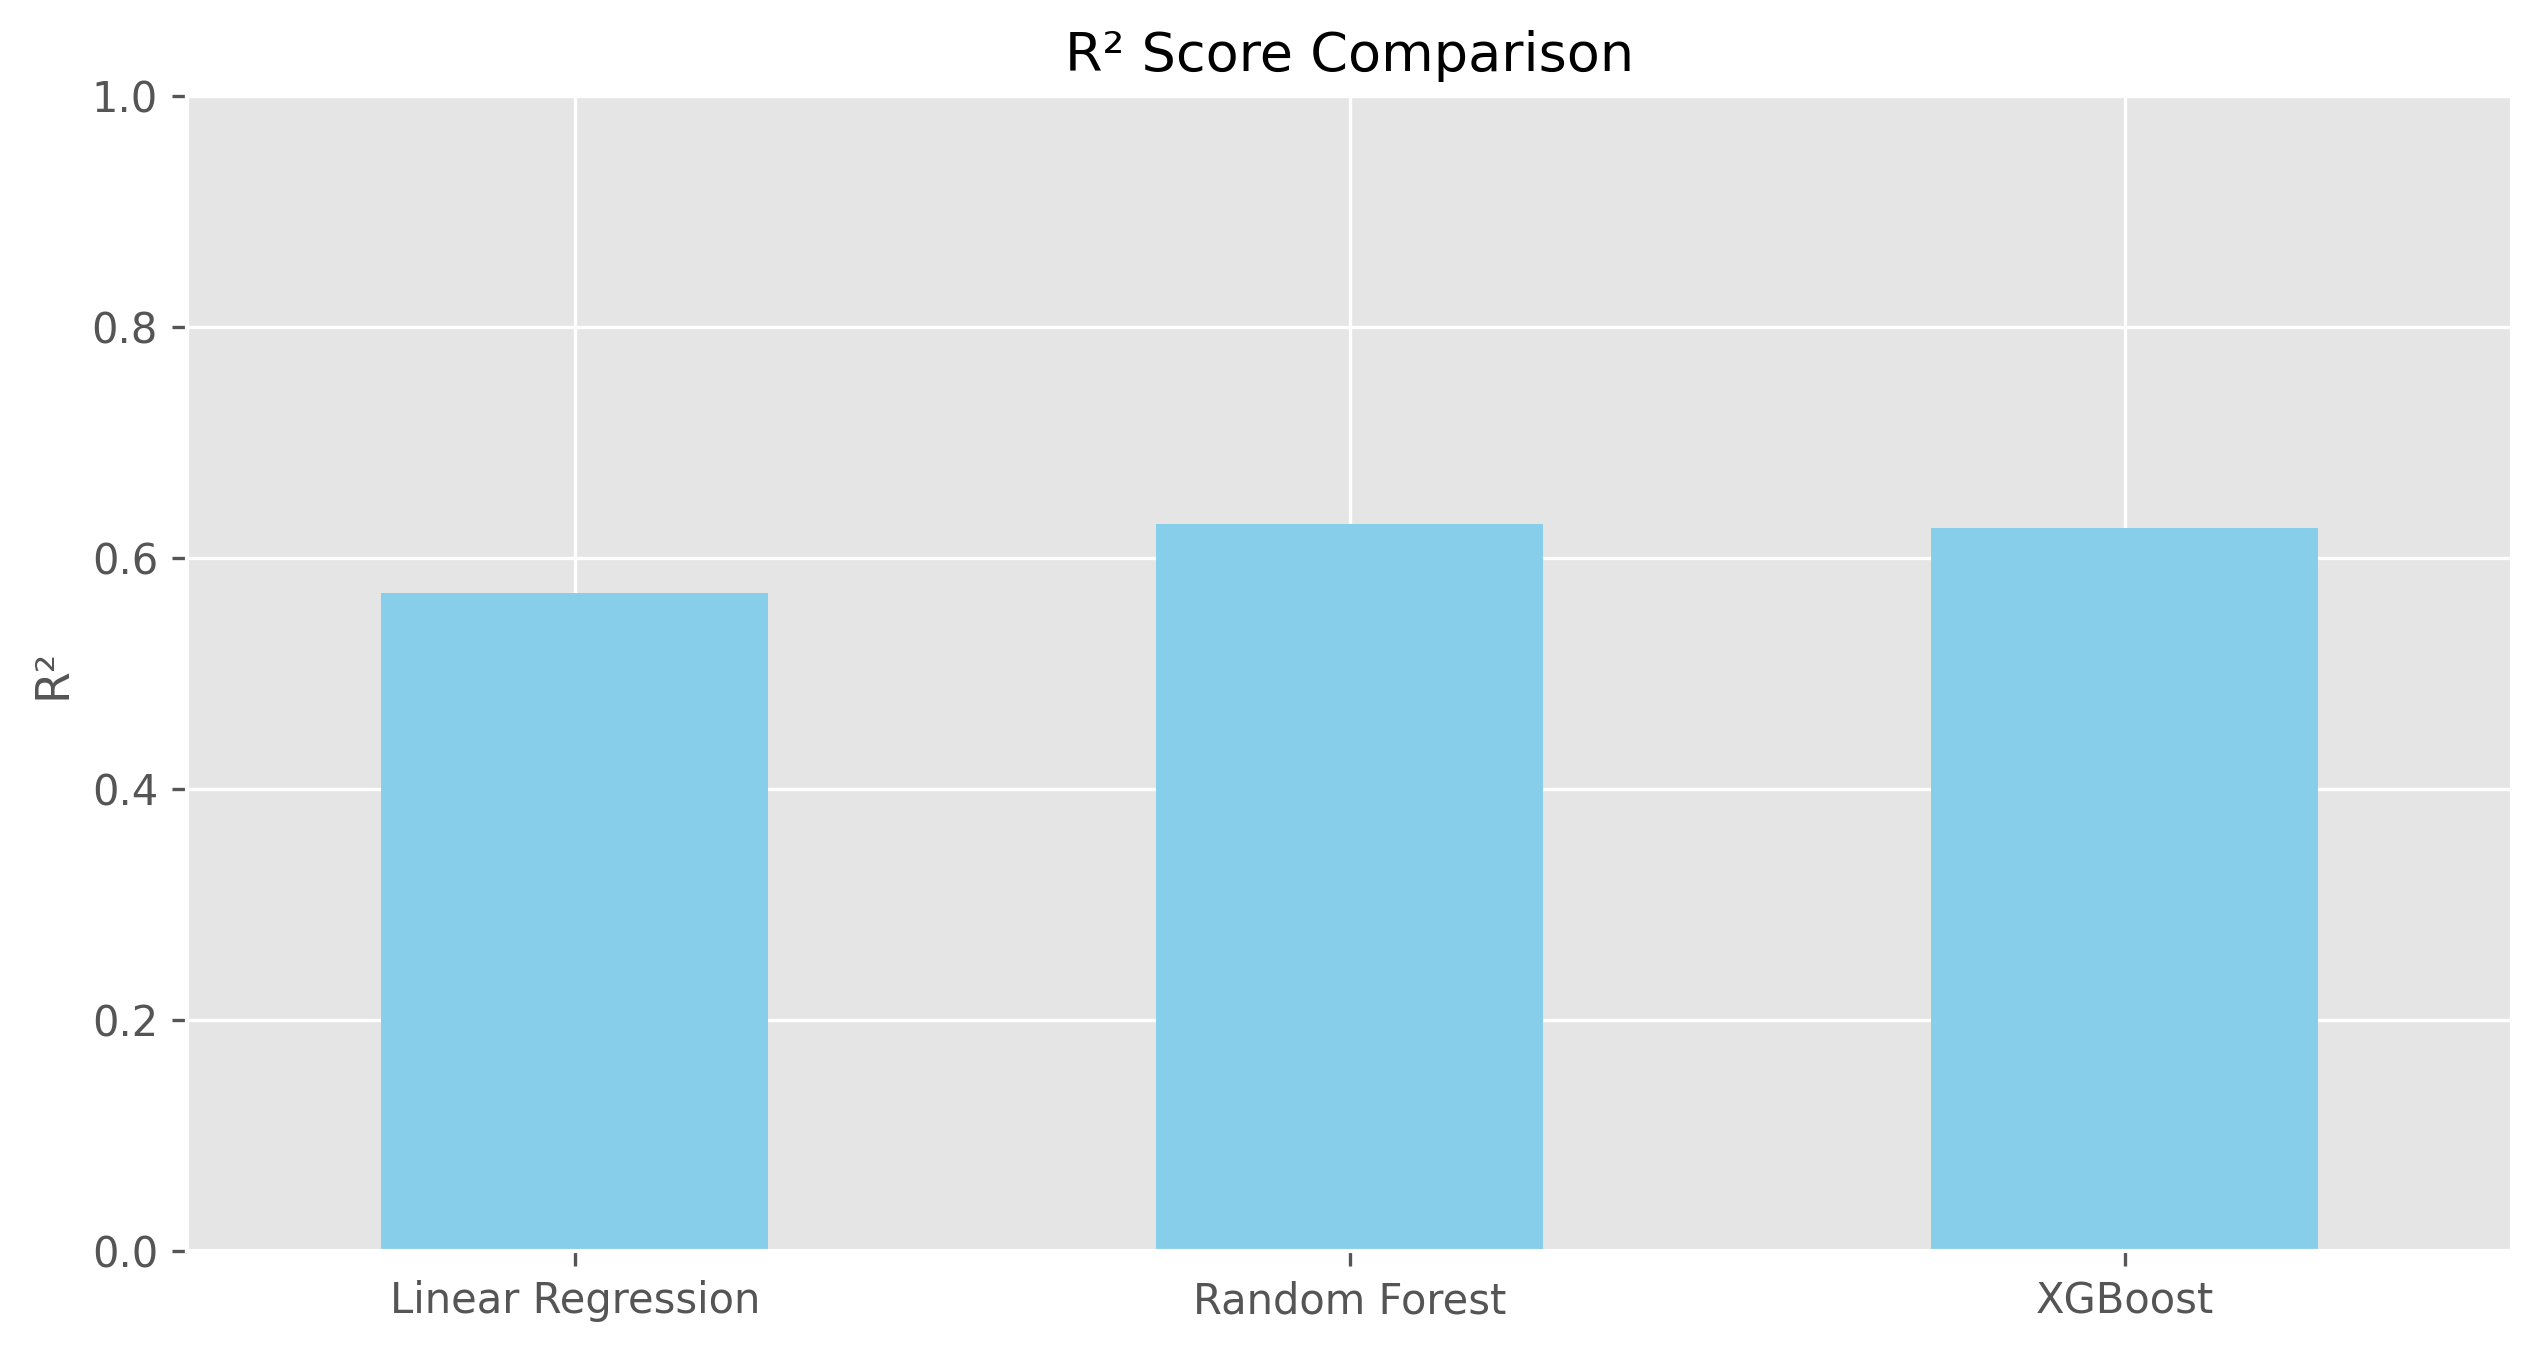

In [7]:
# Compare Results
results_df = pd.DataFrame(results).T
print(results_df)

plt.figure(figsize=(10, 5))
results_df['R2'].plot(kind='bar', color='skyblue')
plt.title('R² Score Comparison')
plt.ylabel('R²')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()
